In [ ]:
# step 1: Mount the drive first
from google.colab import drive
drive.mount("/content/drive/")

# step 2: Add the path of virtual environment (colab_env) site-packages
# to colaboratory system path
import sys
sys.path.append("/content/drive/MyDrive/MISY436/misy_436_base/lib/python3.12/site-packages")


# step 3: Add the path to your course folder
import os
os.chdir('/content/drive/MyDrive/MISY436')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Exercise 2: LDA (25 pts)

## Name: SIDNEY DARANGWA

We will look at LDA on another Corpus.

Create a <font color = red> SHORTCUT </font> to the following file in your Folder for the Course. DO NOT attempt to download!

[Link to data set](https://drive.google.com/file/d/1NLbQFT0KW7GPfZh36Ez-S4kJffLU8HPo/view?usp=sharing)
- Open the link above
- File > Create Shortcut in Drive
- Move the shortcut to your folder for the course


This exercise must be sumbitted to Canvas by the end of class.

Remember to:
- **Share** the file with: jaredws@udel.edu & bonyy@udel.edu
- Export and submit the html version to Canvas
- Comment the Shared link to your `html` submission.

In [ ]:
import polars as pl
from polars import col

df = pl.read_ipc("/content/drive/MyDrive/MISY436/sec_letters_extracted.feather")
df.head()

file_name,letter_head,headings,paragraph_text
str,str,str,str
"""2005-12-06 05_00_00_0001097503…","""Mail Stop 3561 November 16, 20…","""(intro)""","""We have reviewed your filing a…"
"""2005-12-06 05_00_00_0001097503…","""Mail Stop 3561 November 16, 20…","""Appendix: Road Show Presentati…","""9. We note your disclosure on …"
"""2005-12-06 05_00_00_0001097503…","""Mail Stop 3561 November 16, 20…","""General""","""1. We continue to evaluate you…"
"""2005-12-06 05_00_00_0001097503…","""Mail Stop 3561 November 16, 20…","""Item 15, Recent Sales of Unreg…","""10. We note the new disclosure…"
"""2005-12-06 05_00_00_0001097503…","""Mail Stop 3561 November 16, 20…","""Legal Branch Chief""","""cc: via facsimile (212) 841-10…"


In [ ]:
df.shape

(82282, 4)

In [ ]:
(
  ## Unique filings
  df
  .group_by(col.file_name)
  .agg(header_counts = col.file_name.count())

)## 5,352 unique letters!

file_name,header_counts
str,u32
"""2019-10-08 04_00_00_0001781755…",19
"""2013-09-24 04_00_00_0001585064…",30
"""2019-03-07 05_00_00_0001757715…",16
"""2020-08-10 04_00_00_0001801834…",7
"""2007-07-05 04_00_00_0001396838…",13
…,…
"""2013-12-06 05_00_00_0001560186…",13
"""2014-11-03 05_00_00_0001590364…",5
"""2015-07-23 04_00_00_0001512673…",43


In [ ]:
(
    ## Whats the avg number of headings in a letter
    df
    .group_by(col.file_name)
    .agg(header_counts = col.file_name.count())
    .with_columns(avg_headers = col.header_counts.mean())
) ## Avg about 15 headings

file_name,header_counts,avg_headers
str,u32,f64
"""2020-02-04 05_00_00_0001643269…",8,15.374066
"""2013-07-17 04_00_00_0001434316…",26,15.374066
"""2016-05-19 04_00_00_0001671933…",31,15.374066
"""2010-08-27 04_00_00_0001490892…",7,15.374066
"""2012-11-14 05_00_00_0001024305…",20,15.374066
…,…,…
"""2011-03-23 04_00_00_0001122388…",9,15.374066
"""2010-06-17 04_00_00_0001408710…",9,15.374066
"""2007-05-01 04_00_00_0001171662…",11,15.374066


In [ ]:
#how long is the avg section ?
(
    df
    .with_columns(char_length = col.paragraph_text.str.len_chars())
    .select(col.char_length.mean())
    .mean()
)## Avg about 481 char in each section

char_length
f64
481.441397


In [ ]:
## Common Headings
(
    df
    .group_by(col.headings)
    .agg(count = col.headings.count())
    .sort('count', descending=True)
    .head(10)
)

headings,count
str,u32
"""(intro)""",5333
"""Sincerely,""",5126
"""Assistant Director""",2827
"""General""",2580
"""FirstName LastName""",2030
"""Division of Corporation Financ…",1084
"""Prospectus Summary, page 1""",1057
"""Management’s Discussion and An…",849
"""Prospectus Summary""",651


## Parse With Spacy

### Let's use a bigger spacy model

[spaCy English models](https://spacy.io/models/en)

In [ ]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 2.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
import pickle as pk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from tqdm.auto import tqdm

## We can use other models!
nlp = spacy.load("en_core_web_lg")

### Parse with spaCy

AND SAVE

In [ ]:
#Lets pull out our general section text
general_text = (
    df
    .filter(col.headings == "General")
    .select(col.paragraph_text)
    .to_series()
    .to_list()
)
len(general_text)

2580

In [ ]:
'''
parsed_text = []
## Now let's use nlp.pipe for faster processing
## nlp has a default batch size as well.
print(nlp.bat)
docs = nlp.pipe(general_text)
for doc in tqdm(docs, total = len(general_text)):
    tokens = []
    for token in doc:
        # Remove stopwords, punctuation, and non-alphabetic tokens
        if not token.is_stop and not token.is_punct and token.is_alpha:
            tokens.append(token.lemma_) # Use lemmatization
    parsed_text.append(" ".join(tokens))
with open('sec_general_parsed_text.pkl','wb') as f:
  pk.dump(parsed_text, f)
'''

'\nparsed_text = []\n## Now let\'s use nlp.pipe for faster processing\n## nlp has a default batch size as well.\nprint(nlp.bat)\ndocs = nlp.pipe(general_text)\nfor doc in tqdm(docs, total = len(general_text)):\n    tokens = []\n    for token in doc:\n        # Remove stopwords, punctuation, and non-alphabetic tokens\n        if not token.is_stop and not token.is_punct and token.is_alpha:\n            tokens.append(token.lemma_) # Use lemmatization\n    parsed_text.append(" ".join(tokens))\nwith open(\'sec_general_parsed_text.pkl\',\'wb\') as f:\n  pk.dump(parsed_text, f)\n'

### Load in Parsed Text

[Link to parsed text](https://drive.google.com/file/d/1zXEefvsH63rgKABaHHBzqy-iteTxWoVe/view?usp=sharing)

In [ ]:
parsed_text = []
with open('/content/drive/MyDrive/MISY436/sec_general_parsed_text.pkl', 'rb') as f:
  parsed_text = pk.load(f)

### Vectorize

In [ ]:
print("Vectorizing documents...")

count_vectorizer = CountVectorizer(max_df=0.95,
                                   min_df=0.05,
                                   stop_words='english')

data_vectorized = count_vectorizer.fit_transform(tqdm(parsed_text,
                                                      desc = 'Vectorizing Counts:',
                                                      total = len(parsed_text)))
feature_names = count_vectorizer.get_feature_names_out()
print("Vectorization complete.")

Vectorizing documents...


Vectorizing Counts::   0%|          | 0/2071 [00:00<?, ?it/s]

Vectorization complete.


## Train LDA Models

AND SAVE

In [ ]:
'''
## Put our LDA Call in a loop:
models = [] ## Keep track of each model

for num_topics in tqdm(num_topics_list): ## Tqdm for a progress bar :-)
  ## We need to re-instanciate the model on each loop
  lda_model = LatentDirichletAllocation(n_components=num_topics,       # Number of topics
                                        max_iter=100,                # Max learning iterations
                                        learning_method='online',    # Use online learning for large datasets
                                        random_state=42,             # Random state for reproducibility
                                        batch_size=500,              # Documents in each learning iteration
                                        evaluate_every=-1,           # Don't evaluate perplexity
                                        n_jobs=-1                    # Use multiple CPUs
  )
  lda_output = lda_model.fit_transform(data_vectorized)
  models.append(lda_model)
  ## that took a while! Let's save the result so we don't need to re-run it later
with open('sec_letters_general_lda_models.pkl','wb') as f:
  pk.dump(models, f)
'''

"\n## Put our LDA Call in a loop:\nmodels = [] ## Keep track of each model\n\nfor num_topics in tqdm(num_topics_list): ## Tqdm for a progress bar :-)\n  ## We need to re-instanciate the model on each loop\n  lda_model = LatentDirichletAllocation(n_components=num_topics,       # Number of topics\n                                        max_iter=100,                # Max learning iterations\n                                        learning_method='online',    # Use online learning for large datasets\n                                        random_state=42,             # Random state for reproducibility\n                                        batch_size=500,              # Documents in each learning iteration\n                                        evaluate_every=-1,           # Don't evaluate perplexity\n                                        n_jobs=-1                    # Use multiple CPUs\n  )\n  lda_output = lda_model.fit_transform(data_vectorized)\n  models.append(lda_model)\n  ##

### Load Models

[Link to trained models](https://drive.google.com/file/d/1Lv129Vwa2_dWkhH62WPqIQ7AVngUVuYM/view?usp=sharing)

In [ ]:
## Load
models = []
with open('/content/drive/MyDrive/MISY436/sec_letters_general_lda_models.pkl','rb') as f:
  models = pk.load(f)

In [ ]:
len(models)

13

In [ ]:
models[0]

LatentDirichletAllocation(batch_size=500, learning_method='online',
                          max_iter=100, n_components=2, n_jobs=-1,
                          random_state=42)

## Evaluate

In [ ]:
import numpy as np
num_topics_list =np.arange(2, 15,1)
num_topics_list

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [ ]:
perplexity_scores = []
num_topics_list = [model.n_components for model in models] # Reconstruct num_topics_list from models
print("Calcualting Perplexity ...")
for i, model in tqdm(enumerate(models), total= len(models)):
  num_topics = num_topics_list[i]
  perplexity = model.perplexity(data_vectorized)
  perplexity_scores.append((perplexity))

# Prepare data for plotting
plot_df = pl.DataFrame({
    'Number_of_Topics': num_topics_list,
    'Perplexity': perplexity_scores
})


from sklearn.metrics.pairwise import cosine_similarity

def calculate_cao_juan_score(topic_word_distribution):
    num_topics = topic_word_distribution.shape[0]
    cosine_similarities = []

    ## We need 2 or more topics to have similarity between them
    if num_topics < 2:
        return np.nan # Or 0, depending on desired behavior for single/no topics

    for i in range(num_topics):
        for j in range(i + 1, num_topics):
            # Reshape for cosine_similarity function (expects 2D arrays)
            similarity = cosine_similarity(topic_word_distribution[i].reshape(1, -1),
                                           topic_word_distribution[j].reshape(1, -1))[0][0]
            cosine_similarities.append(similarity)

    return np.mean(cosine_similarities)

cao_juan_scores = []

print("Calculating Cosine Similarity ...")
for i, model in tqdm(enumerate(models), total = len(models)):
  score = calculate_cao_juan_score(model.components_)
  cao_juan_scores.append(score)

plot_df = (
    plot_df
    .with_columns(Cao_Juan = pl.Series(cao_juan_scores))
    )

Calcualting Perplexity ...


  0%|          | 0/13 [00:00<?, ?it/s]

Calculating Cosine Similarity ...


  0%|          | 0/13 [00:00<?, ?it/s]

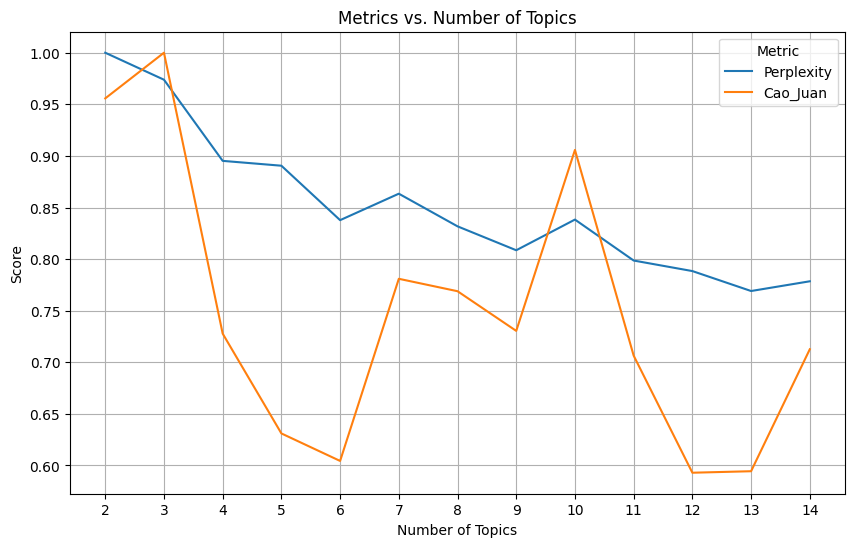

In [ ]:
## I'll use the MinMax Scaler this time
from polars import col
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np


plot_df2 = (
    plot_df
    .with_columns(
        Perplexity = col.Perplexity / col.Perplexity.max(),
        Cao_Juan = col.Cao_Juan / col.Cao_Juan.max())
    )

## make TAll
plot_df_tall = plot_df2.unpivot(index = ['Number_of_Topics'],
                            on = ['Perplexity', 'Cao_Juan'],
                            value_name = 'Score',
                            variable_name = 'Metric')

## Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df_tall, x='Number_of_Topics', y='Score', hue = 'Metric')
plt.title('Metrics vs. Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Score')
plt.xticks(num_topics_list)
plt.grid(True)
plt.show()

###  Word Clouds

In [ ]:
## Which model?
models[0]

LatentDirichletAllocation(batch_size=500, learning_method='online',
                          max_iter=100, n_components=2, n_jobs=-1,
                          random_state=42)

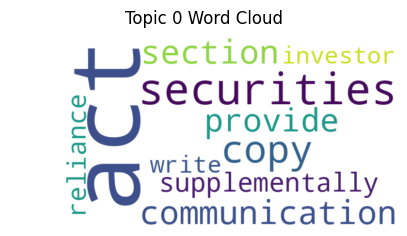

------------------------------------------------------------


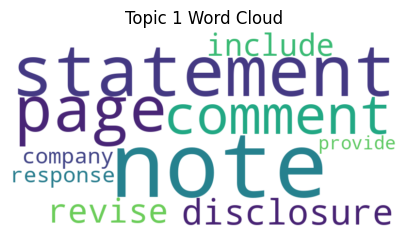

------------------------------------------------------------


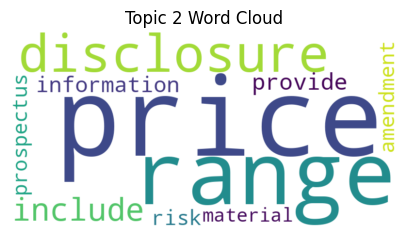

------------------------------------------------------------


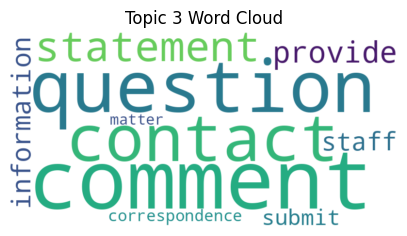

------------------------------------------------------------


In [ ]:
## 4, 5, or 6 look like a good place to start
## Perhaps 12 could be investigated later
## We tend to prefer SMALLER number of Topics

from wordcloud import WordCloud

def plot_word_clouds(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        # Get top words and their weights for the current topic
        topic_words = {feature_names[i]: topic[i] for i in topic.argsort()[:-no_top_words - 1:-1]}

        # Create a WordCloud object
        wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate_from_frequencies(topic_words)

        # Display the generated image:
        plt.figure(figsize=(5, 3))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Topic {topic_idx} Word Cloud')
        plt.show()
        print("---"*20)

plot_word_clouds(models[2], feature_names, 10) # Using model with 4 topics as an example

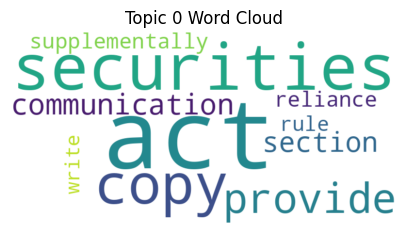

------------------------------------------------------------


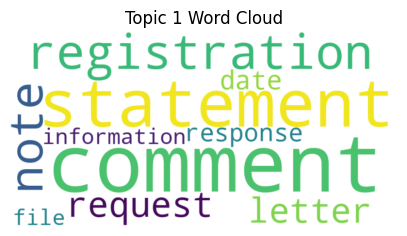

------------------------------------------------------------


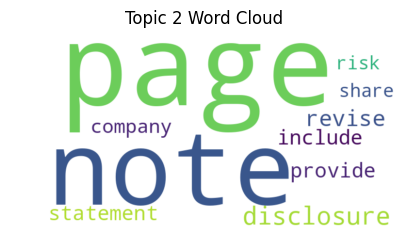

------------------------------------------------------------


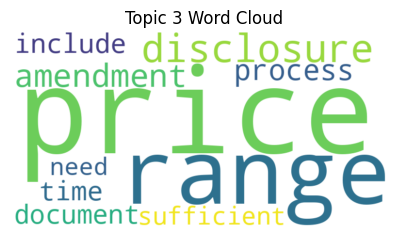

------------------------------------------------------------


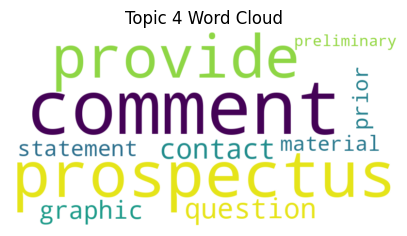

------------------------------------------------------------


In [ ]:
plot_word_clouds(models[3], feature_names, 10)

In [ ]:
!jupyter nbconvert --to html Exercise2.ipynb

[NbConvertApp] WARNING | pattern 'Exercise.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Ex